# Pandas Mastery: From Zero to Real-World Data Analysis

A practical, progressive notebook covering the core Pandas concepts used in everyday
data analysis, data cleaning, reporting, and exploratory analysis.

**Recommended workflow:** read the explanation, run the examples, then solve each exercise
before looking at the next section.

## What you will learn

- Series and DataFrames
- Indexing and selection
- Boolean filtering
- Data cleaning and missing values
- Data types and categorical data
- Text and datetime manipulation
- Sorting, ranking, and duplicates
- GroupBy and aggregation
- `transform`, `filter`, and `agg`
- `map`, `apply`, and vectorization
- `concat`, `merge`, and joins
- Pivot tables and reshaping
- MultiIndex
- Time series and rolling windows
- Exploratory data analysis
- Visualization
- Reading and writing files
- Performance and best practices
- A complete final project

## Table of Contents

1. Setup
2. Series fundamentals
3. DataFrame fundamentals
4. Creating DataFrames
5. Reading and writing files
6. Inspecting data
7. Selecting columns
8. `loc` and `iloc`
9. Boolean filtering
10. Creating and updating columns
11. Sorting and ranking
12. Data types
13. Missing values
14. Duplicates
15. String operations
16. Datetime operations
17. Indexes
18. GroupBy
19. Aggregation
20. `transform`, `filter`, and group calculations
21. `map`, `apply`, and vectorization
22. Concatenation
23. Merge and joins
24. Pivot tables
25. Melt and reshaping
26. MultiIndex
27. Time series and rolling windows
28. Exploratory Data Analysis
29. Visualization
30. File formats and practical I/O
31. Performance and best practices
32. End-to-end project
33. Final challenge

# 1. Setup

Pandas is conventionally imported as `pd`. NumPy is useful for numerical operations and generating sample data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Pandas:", pd.__version__)

Pandas: 2.3.1


# 2. Series Fundamentals

A `Series` is a one-dimensional labeled array.

A useful mental model is:

> **Series = one column + an index**

In [2]:
ages = pd.Series([24, 31, 42, 28, 36])
ages

0    24
1    31
2    42
3    28
4    36
dtype: int64

In [3]:
print(ages.values)
print(ages.index)
print(ages.mean())
print(ages.median())
print(ages.std())
print(ages.min())
print(ages.max())

[24 31 42 28 36]
RangeIndex(start=0, stop=5, step=1)
32.2
31.0
7.014271166700073
24
42


In [4]:
scores = pd.Series(
    [85, 92, 78, 96],
    index=["Alice", "Bob", "Charlie", "Diana"],
    name="score"
)

scores["Bob"], scores.loc["Diana"], scores.iloc[0]

(np.int64(92), np.int64(96), np.int64(85))

### Exercise

Create a Series named `temperatures` with five temperatures.

Calculate:

- mean
- median
- minimum
- maximum
- standard deviation

In [ ]:
# Your solution here

# 3. DataFrame Fundamentals

A DataFrame is a two-dimensional labeled table.

Each column is a Series, and all columns share the same row index.

In [5]:
df = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie", "Diana"],
    "age": [25, 31, 42, 28],
    "department": ["Engineering", "Sales", "Engineering", "Marketing"],
    "salary": [60000, 52000, 85000, 58000]
})

df

,name,age,department,salary
0,Alice,25,Engineering,60000
1,Bob,31,Sales,52000
2,Charlie,42,Engineering,85000
3,Diana,28,Marketing,58000


In [6]:
print("Rows:", len(df))
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Rows: 4
Shape: (4, 4)
Columns: ['name', 'age', 'department', 'salary']


# 4. Creating DataFrames

DataFrames can come from dictionaries, lists, records, NumPy arrays, JSON, SQL queries, and more.

In [7]:
records = [
    {"name": "Ana", "age": 30, "city": "Bogota"},
    {"name": "Luis", "age": 35, "city": "Medellin"},
    {"name": "Sara", "age": 27, "city": "Cali"},
]

people = pd.DataFrame(records)
people

,name,age,city
0,Ana,30,Bogota
1,Luis,35,Medellin
2,Sara,27,Cali


In [8]:
array_df = pd.DataFrame(
    np.arange(12).reshape(4, 3),
    columns=["A", "B", "C"]
)

array_df

,A,B,C
0,0,1,2
1,3,4,5
2,6,7,8
3,9,10,11


# 5. Reading and Writing Files

Common I/O functions include:

```python
pd.read_csv()
pd.read_excel()
pd.read_json()
pd.read_parquet()
df.to_csv()
df.to_excel()
df.to_json()
df.to_parquet()
```

For portability, this notebook creates a small CSV locally.

In [9]:
df.to_csv("employees.csv", index=False)
loaded = pd.read_csv("employees.csv")
loaded

,name,age,department,salary
0,Alice,25,Engineering,60000
1,Bob,31,Sales,52000
2,Charlie,42,Engineering,85000
3,Diana,28,Marketing,58000


When reading real data, useful parameters include:

- `usecols` — load only required columns
- `dtype` — control data types
- `parse_dates` — parse dates while loading
- `na_values` — define custom missing-value markers
- `nrows` — inspect only part of a large file
- `chunksize` — process large files in batches

# 6. Inspecting Data

Always inspect a dataset before transforming it.

In [10]:
df.head(3)

,name,age,department,salary
0,Alice,25,Engineering,60000
1,Bob,31,Sales,52000
2,Charlie,42,Engineering,85000


In [11]:
df.tail(2)

,name,age,department,salary
2,Charlie,42,Engineering,85000
3,Diana,28,Marketing,58000


In [12]:
df.sample(2, random_state=1)

,name,age,department,salary
3,Diana,28,Marketing,58000
2,Charlie,42,Engineering,85000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        4 non-null      object
 1   age         4 non-null      int64 
 2   department  4 non-null      object
 3   salary      4 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 260.0+ bytes


In [14]:
df.describe()

,age,salary
count,4.000000,4.000000
mean,31.500000,63750.000000
std,7.416198,14568.802284
min,25.000000,52000.000000
25%,27.250000,56500.000000
50%,29.500000,59000.000000
75%,33.750000,66250.000000
max,42.000000,85000.000000


In [15]:
df.describe(include="all")

,name,age,department,salary
count,4,4.000000,4,4.000000
unique,4,NaN,3,NaN
top,Alice,NaN,Engineering,NaN
freq,1,NaN,2,NaN
mean,NaN,31.500000,NaN,63750.000000
std,NaN,7.416198,NaN,14568.802284
min,NaN,25.000000,NaN,52000.000000
25%,NaN,27.250000,NaN,56500.000000
50%,NaN,29.500000,NaN,59000.000000
75%,NaN,33.750000,NaN,66250.000000


In [16]:
df.nunique()

name          4
age           4
department    3
salary        4
dtype: int64

Useful first questions:

- How many rows and columns are there?
- What are the column names?
- What are the data types?
- How many missing values exist?
- Are there duplicates?
- What are the numerical ranges?
- What values occur in categorical columns?

# 7. Selecting Columns

In [17]:
df["name"]

0      Alice
1        Bob
2    Charlie
3      Diana
Name: name, dtype: object

In [18]:
df[["name", "department", "salary"]]

,name,department,salary
0,Alice,Engineering,60000
1,Bob,Sales,52000
2,Charlie,Engineering,85000
3,Diana,Marketing,58000


Bracket notation is generally safer than attribute notation because column names may contain spaces or conflict with DataFrame attributes.

In [19]:
df.salary

0    60000
1    52000
2    85000
3    58000
Name: salary, dtype: int64

# 8. `loc` and `iloc`

`loc` is label-based. `iloc` is position-based.

In [20]:
df.loc[0]

name                Alice
age                    25
department    Engineering
salary              60000
Name: 0, dtype: object

In [21]:
df.loc[0:2, ["name", "salary"]]

,name,salary
0,Alice,60000
1,Bob,52000
2,Charlie,85000


In [22]:
df.iloc[0]

name                Alice
age                    25
department    Engineering
salary              60000
Name: 0, dtype: object

In [23]:
df.iloc[0:3, 0:2]

,name,age
0,Alice,25
1,Bob,31
2,Charlie,42


`loc` is particularly important because it can combine labels and Boolean conditions:

```python
df.loc[df["salary"] > 60000, ["name", "salary"]]
```

In [24]:
df.loc[df["salary"] > 60000, ["name", "salary"]]

,name,salary
2,Charlie,85000


# 9. Boolean Filtering

In [25]:
df[df["salary"] > 60000]

,name,age,department,salary
2,Charlie,42,Engineering,85000


In [26]:
df[(df["salary"] > 50000) & (df["age"] < 40)]

,name,age,department,salary
0,Alice,25,Engineering,60000
1,Bob,31,Sales,52000
3,Diana,28,Marketing,58000


In [27]:
df[(df["department"] == "Engineering") | (df["salary"] > 70000)]

,name,age,department,salary
0,Alice,25,Engineering,60000
2,Charlie,42,Engineering,85000


In [28]:
df[df["department"].isin(["Engineering", "Marketing"])]

,name,age,department,salary
0,Alice,25,Engineering,60000
2,Charlie,42,Engineering,85000
3,Diana,28,Marketing,58000


In [29]:
df[df["salary"].between(55000, 85000)]

,name,age,department,salary
0,Alice,25,Engineering,60000
2,Charlie,42,Engineering,85000
3,Diana,28,Marketing,58000


In [30]:
df.query("salary > 50000 and age < 40")

,name,age,department,salary
0,Alice,25,Engineering,60000
1,Bob,31,Sales,52000
3,Diana,28,Marketing,58000


Remember:

- `&` = AND
- `|` = OR
- `~` = NOT

Use parentheses around each condition.

# 10. Creating and Updating Columns

In [31]:
df["salary_k"] = df["salary"] / 1000
df["age_next_year"] = df["age"] + 1
df["bonus"] = df["salary"] * 0.10
df["total_compensation"] = df["salary"] + df["bonus"]

df

,name,age,department,salary,salary_k,age_next_year,bonus,total_compensation
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0
1,Bob,31,Sales,52000,52.0,32,5200.0,57200.0
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0
3,Diana,28,Marketing,58000,58.0,29,5800.0,63800.0


In [32]:
df["seniority"] = np.where(df["age"] >= 35, "Senior", "Junior")
df

,name,age,department,salary,salary_k,age_next_year,bonus,total_compensation,seniority
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior
1,Bob,31,Sales,52000,52.0,32,5200.0,57200.0,Junior
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior
3,Diana,28,Marketing,58000,58.0,29,5800.0,63800.0,Junior


In [34]:
conditions = [
    df["salary"] >= 80000,
    df["salary"] >= 60000,
    df["salary"] < 60000
]
choices = ["High", "Medium", "Low"]

df["salary_band"] = np.select(conditions, choices, "na")
df

,name,age,department,salary,salary_k,age_next_year,bonus,total_compensation,seniority,salary_band
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior,Medium
1,Bob,31,Sales,52000,52.0,32,5200.0,57200.0,Junior,Low
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior,High
3,Diana,28,Marketing,58000,58.0,29,5800.0,63800.0,Junior,Low


### `assign()`

`assign()` is useful when building readable transformation pipelines.

In [35]:
result = (
    df
    .assign(salary_k=lambda x: x["salary"] / 1000)
    .assign(bonus=lambda x: x["salary"] * 0.10)
)

result[["name", "salary", "salary_k", "bonus"]]

,name,salary,salary_k,bonus
0,Alice,60000,60.0,6000.0
1,Bob,52000,52.0,5200.0
2,Charlie,85000,85.0,8500.0
3,Diana,58000,58.0,5800.0


# 11. Sorting and Ranking

In [36]:
df.sort_values("salary", ascending=False)

,name,age,department,salary,salary_k,age_next_year,bonus,total_compensation,seniority,salary_band
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior,High
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior,Medium
3,Diana,28,Marketing,58000,58.0,29,5800.0,63800.0,Junior,Low
1,Bob,31,Sales,52000,52.0,32,5200.0,57200.0,Junior,Low


In [37]:
df.sort_values(
    ["department", "salary"],
    ascending=[True, False]
)

,name,age,department,salary,salary_k,age_next_year,bonus,total_compensation,seniority,salary_band
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior,High
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior,Medium
3,Diana,28,Marketing,58000,58.0,29,5800.0,63800.0,Junior,Low
1,Bob,31,Sales,52000,52.0,32,5200.0,57200.0,Junior,Low


In [39]:
df["salary_rank"] = df["salary"].rank(method="dense", ascending=False)
df[["name", "salary", "salary_rank"]]

,name,salary,salary_rank
0,Alice,60000,2.0
1,Bob,52000,4.0
2,Charlie,85000,1.0
3,Diana,58000,3.0


# 12. Data Types

In [40]:
df.dtypes

name                   object
age                     int64
department             object
salary                  int64
salary_k              float64
age_next_year           int64
bonus                 float64
total_compensation    float64
seniority              object
salary_band            object
salary_rank           float64
dtype: object

In [41]:
example_types = pd.DataFrame({
    "integer": [1, 2, 3],
    "decimal": [1.5, 2.5, 3.5],
    "text": ["A", "B", "C"],
    "boolean": [True, False, True]
})

example_types.dtypes

integer      int64
decimal    float64
text        object
boolean       bool
dtype: object

Common types:

- integer
- float
- boolean
- string/object
- category
- datetime
- timedelta

Use explicit conversion when cleaning external data.

In [42]:
messy_numbers = pd.Series(["10", "20", "not available", "40"])

pd.to_numeric(messy_numbers, errors="coerce")

0    10.0
1    20.0
2     NaN
3    40.0
dtype: float64

# 13. Missing Values

In [43]:
messy = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie", "Diana", "Eva"],
    "age": [25, np.nan, 42, 28, np.nan],
    "salary": [60000, 52000, np.nan, 58000, 70000]
})

messy

,name,age,salary
0,Alice,25.0,60000.0
1,Bob,NaN,52000.0
2,Charlie,42.0,NaN
3,Diana,28.0,58000.0
4,Eva,NaN,70000.0


In [44]:
messy.isna()

,name,age,salary
0,False,False,False
1,False,True,False
2,False,False,True
3,False,False,False
4,False,True,False


In [45]:
messy.isna().sum()

name      0
age       2
salary    1
dtype: int64

In [46]:
messy.dropna()

,name,age,salary
0,Alice,25.0,60000.0
3,Diana,28.0,58000.0


In [47]:
messy.fillna({
    "age": messy["age"].median(),
    "salary": messy["salary"].median()
})

,name,age,salary
0,Alice,25.0,60000.0
1,Bob,28.0,52000.0
2,Charlie,42.0,59000.0
3,Diana,28.0,58000.0
4,Eva,28.0,70000.0


Other useful operations:

- `isna()`
- `notna()`
- `dropna()`
- `fillna()`
- `ffill()`
- `bfill()`

The correct strategy depends on what the missing value means.

In [48]:
series = pd.Series([10, np.nan, np.nan, 40, 50])
series.ffill()

0    10.0
1    10.0
2    10.0
3    40.0
4    50.0
dtype: float64

# 14. Duplicates

In [49]:
duplicates = pd.DataFrame({
    "customer": ["A", "B", "B", "C", "C"],
    "city": ["Bogota", "Cali", "Cali", "Medellin", "Medellin"],
    "orders": [3, 4, 4, 2, 2]
})

duplicates.duplicated()

0    False
1    False
2     True
3    False
4     True
dtype: bool

In [50]:
duplicates.drop_duplicates()

,customer,city,orders
0,A,Bogota,3
1,B,Cali,4
3,C,Medellin,2


In [51]:
duplicates.drop_duplicates(subset=["customer"])

,customer,city,orders
0,A,Bogota,3
1,B,Cali,4
3,C,Medellin,2


Be careful: removing duplicates by a subset is a business rule, not merely a technical cleanup.

# 15. String Operations

Pandas provides vectorized string operations through `.str`.

In [52]:
names = pd.Series([" Alice ", "BOB", "charlie", "Diana"])

names.str.strip().str.title()

0      Alice
1        Bob
2    Charlie
3      Diana
dtype: object

In [53]:
emails = pd.Series([
    "alice@example.com",
    "bob@test.com",
    "charlie@example.com"
])

emails.str.lower()

0      alice@example.com
1           bob@test.com
2    charlie@example.com
dtype: object

In [54]:
emails.str.split("@").str[-1]

0    example.com
1       test.com
2    example.com
dtype: object

In [55]:
emails.str.contains("example.com")

0     True
1    False
2     True
dtype: bool

In [56]:
names.str.len()

0    7
1    3
2    7
3    5
dtype: int64

In [57]:
names.str.replace(" ", "_", regex=False)

0    _Alice_
1        BOB
2    charlie
3      Diana
dtype: object

# 16. Datetime Operations

In [58]:
orders = pd.DataFrame({
    "order_id": [1, 2, 3, 4],
    "order_date": ["2026-01-15", "2026-02-20", "2026-02-25", "2026-03-10"],
    "amount": [120, 250, 90, 400]
})

orders["order_date"] = pd.to_datetime(orders["order_date"])
orders

,order_id,order_date,amount
0,1,2026-01-15,120
1,2,2026-02-20,250
2,3,2026-02-25,90
3,4,2026-03-10,400


In [59]:
orders["year"] = orders["order_date"].dt.year
orders["month"] = orders["order_date"].dt.month
orders["month_name"] = orders["order_date"].dt.month_name()
orders["weekday"] = orders["order_date"].dt.day_name()

orders

,order_id,order_date,amount,year,month,month_name,weekday
0,1,2026-01-15,120,2026,1,January,Thursday
1,2,2026-02-20,250,2026,2,February,Friday
2,3,2026-02-25,90,2026,2,February,Wednesday
3,4,2026-03-10,400,2026,3,March,Tuesday


In [60]:
orders["days_since_order"] = pd.Timestamp("2026-04-01") - orders["order_date"]
orders

,order_id,order_date,amount,year,month,month_name,weekday,days_since_order
0,1,2026-01-15,120,2026,1,January,Thursday,76 days
1,2,2026-02-20,250,2026,2,February,Friday,40 days
2,3,2026-02-25,90,2026,2,February,Wednesday,35 days
3,4,2026-03-10,400,2026,3,March,Tuesday,22 days


Datetime tools you should know:

- `.dt.year`
- `.dt.month`
- `.dt.day`
- `.dt.day_name()`
- `.dt.month_name()`
- `.dt.weekday`
- `.dt.is_month_end`
- `.dt.is_month_start`
- `pd.date_range()`
- `pd.to_datetime()`
- `pd.Timedelta()`

# 17. Indexes

In [61]:
indexed = df.set_index("name")
indexed

,age,department,salary,salary_k,age_next_year,bonus,total_compensation,seniority,salary_band,salary_rank
name,,,,,,,,,,
Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior,Medium,2.0
Bob,31,Sales,52000,52.0,32,5200.0,57200.0,Junior,Low,4.0
Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior,High,1.0
Diana,28,Marketing,58000,58.0,29,5800.0,63800.0,Junior,Low,3.0


In [62]:
indexed.loc["Alice"]

age                            25
department            Engineering
salary                      60000
salary_k                     60.0
age_next_year                  26
bonus                      6000.0
total_compensation        66000.0
seniority                  Junior
salary_band                Medium
salary_rank                   2.0
Name: Alice, dtype: object

In [63]:
indexed.reset_index()

,name,age,department,salary,salary_k,age_next_year,bonus,total_compensation,seniority,salary_band,salary_rank
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior,Medium,2.0
1,Bob,31,Sales,52000,52.0,32,5200.0,57200.0,Junior,Low,4.0
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior,High,1.0
3,Diana,28,Marketing,58000,58.0,29,5800.0,63800.0,Junior,Low,3.0


In [64]:
df.rename(columns={"salary": "annual_salary"})

,name,age,department,annual_salary,salary_k,age_next_year,bonus,total_compensation,seniority,salary_band,salary_rank
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior,Medium,2.0
1,Bob,31,Sales,52000,52.0,32,5200.0,57200.0,Junior,Low,4.0
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior,High,1.0
3,Diana,28,Marketing,58000,58.0,29,5800.0,63800.0,Junior,Low,3.0


Indexes are powerful for alignment and time series. However, do not assume an index is automatically a database-style primary key.

Useful methods:

- `set_index`
- `reset_index`
- `reindex`
- `sort_index`
- `rename`

# 18. GroupBy

`groupby` follows the **Split → Apply → Combine** pattern.

In [65]:
df.groupby("department")["salary"].mean()

department
Engineering    72500.0
Marketing      58000.0
Sales          52000.0
Name: salary, dtype: float64

In [66]:
df.groupby("department")["salary"].sum()

department
Engineering    145000
Marketing       58000
Sales           52000
Name: salary, dtype: int64

In [67]:
df.groupby("department").size()

department
Engineering    2
Marketing      1
Sales          1
dtype: int64

In [68]:
sales = pd.DataFrame({
    "region": ["North", "North", "South", "South", "North", "South"],
    "product": ["A", "B", "A", "B", "A", "B"],
    "sales": [100, 200, 150, 300, 120, 250]
})

sales.groupby(["region", "product"])["sales"].sum()

region  product
North   A          220
        B          200
South   A          150
        B          550
Name: sales, dtype: int64

# 19. Aggregation

`agg()` lets you compute several statistics in one operation.

In [69]:
df.groupby("department")["salary"].agg(
    ["count", "mean", "median", "min", "max", "sum"]
)

,count,mean,median,min,max,sum
department,,,,,,
Engineering,2,72500.0,72500.0,60000,85000,145000
Marketing,1,58000.0,58000.0,58000,58000,58000
Sales,1,52000.0,52000.0,52000,52000,52000


In [70]:
summary = df.groupby("department").agg(
    employee_count=("name", "count"),
    average_salary=("salary", "mean"),
    median_salary=("salary", "median"),
    total_salary=("salary", "sum"),
    oldest_employee=("age", "max")
)

summary

,employee_count,average_salary,median_salary,total_salary,oldest_employee
department,,,,,
Engineering,2,72500.0,72500.0,145000,42
Marketing,1,58000.0,58000.0,58000,28
Sales,1,52000.0,52000.0,52000,31


Named aggregations make grouped results easier to understand and maintain.

# 20. `transform`, `filter`, and Group Calculations

In [71]:
df["department_avg_salary"] = (
    df.groupby("department")["salary"].transform("mean")
)

df["salary_vs_department_avg"] = (
    df["salary"] - df["department_avg_salary"]
)

df[["name", "department", "salary", "department_avg_salary", "salary_vs_department_avg"]]

,name,department,salary,department_avg_salary,salary_vs_department_avg
0,Alice,Engineering,60000,72500.0,-12500.0
1,Bob,Sales,52000,52000.0,0.0
2,Charlie,Engineering,85000,72500.0,12500.0
3,Diana,Marketing,58000,58000.0,0.0


`transform()` returns a result aligned with the original rows, unlike a normal `groupby().agg()` result.

In [72]:
df.groupby("department").filter(lambda group: group["salary"].mean() > 60000)

,name,age,department,salary,salary_k,age_next_year,bonus,total_compensation,seniority,salary_band,salary_rank,department_avg_salary,salary_vs_department_avg
0,Alice,25,Engineering,60000,60.0,26,6000.0,66000.0,Junior,Medium,2.0,72500.0,-12500.0
2,Charlie,42,Engineering,85000,85.0,43,8500.0,93500.0,Senior,High,1.0,72500.0,12500.0


# 21. `map`, `apply`, and Vectorization

In [73]:
department_map = {
    "Engineering": "Tech",
    "Sales": "Commercial",
    "Marketing": "Commercial"
}

df["business_unit"] = df["department"].map(department_map)
df[["department", "business_unit"]]

,department,business_unit
0,Engineering,Tech
1,Sales,Commercial
2,Engineering,Tech
3,Marketing,Commercial


In [75]:
df["salary_label"] = df["salary"].apply(
    lambda x: "High" if x >= 70000 else "Standard"
)

df[["salary", "salary_label"]]

,salary,salary_label
0,60000,Standard
1,52000,Standard
2,85000,High
3,58000,Standard


### Prefer vectorization when possible

This:

```python
df["total"] = df["price"] * df["quantity"]
```

is usually preferable to a row-by-row `apply(axis=1)`.

Use `apply` when the operation cannot be expressed cleanly with existing vectorized operations.

In [76]:
df["description"] = df.apply(
    lambda row: f'{row["name"]} works in {row["department"]}',
    axis=1
)

df[["name", "description"]]

,name,description
0,Alice,Alice works in Engineering
1,Bob,Bob works in Sales
2,Charlie,Charlie works in Engineering
3,Diana,Diana works in Marketing


# 22. Concatenation

`concat()` stacks compatible DataFrames vertically or horizontally.

In [77]:
q1 = pd.DataFrame({"month": ["Jan", "Feb"], "sales": [100, 120]})
q2 = pd.DataFrame({"month": ["Mar", "Apr"], "sales": [150, 130]})

pd.concat([q1, q2], ignore_index=True)

,month,sales
0,Jan,100
1,Feb,120
2,Mar,150
3,Apr,130


In [78]:
left = pd.DataFrame({"A": [1, 2], "B": [3, 4]})
right = pd.DataFrame({"C": [5, 6], "D": [7, 8]})

pd.concat([left, right], axis=1)

,A,B,C,D
0,1,3,5,7
1,2,4,6,8


# 23. Merge and Joins

`merge()` is conceptually similar to SQL joins.

In [79]:
employees = pd.DataFrame({
    "employee_id": [1, 2, 3, 4],
    "name": ["Alice", "Bob", "Charlie", "Diana"],
    "department_id": [10, 20, 10, 30]
})

departments = pd.DataFrame({
    "department_id": [10, 20, 30],
    "department": ["Engineering", "Sales", "Marketing"]
})

employees.merge(departments, on="department_id", how="left")

,employee_id,name,department_id,department
0,1,Alice,10,Engineering
1,2,Bob,20,Sales
2,3,Charlie,10,Engineering
3,4,Diana,30,Marketing


In [80]:
employees.merge(departments, on="department_id", how="inner")

,employee_id,name,department_id,department
0,1,Alice,10,Engineering
1,2,Bob,20,Sales
2,3,Charlie,10,Engineering
3,4,Diana,30,Marketing


Main join types:

- `inner` — matching rows only
- `left` — every row from the left table
- `right` — every row from the right table
- `outer` — all keys from both sides

When possible, use `validate=` to catch unexpected relationships.

In [81]:
employees.merge(
    departments,
    on="department_id",
    how="left",
    validate="many_to_one"
)

,employee_id,name,department_id,department
0,1,Alice,10,Engineering
1,2,Bob,20,Sales
2,3,Charlie,10,Engineering
3,4,Diana,30,Marketing


### Joining on differently named keys

In [82]:
users = pd.DataFrame({
    "user_id": [1, 2, 3],
    "name": ["A", "B", "C"]
})

orders2 = pd.DataFrame({
    "customer_id": [1, 2, 1, 3],
    "amount": [100, 200, 50, 300]
})

orders2.merge(
    users,
    left_on="customer_id",
    right_on="user_id",
    how="left"
)

,customer_id,amount,user_id,name
0,1,100,1,A
1,2,200,2,B
2,1,50,1,A
3,3,300,3,C


# 24. Pivot Tables

In [83]:
monthly_sales = pd.DataFrame({
    "region": ["North", "North", "South", "South", "North", "South"],
    "month": ["Jan", "Feb", "Jan", "Feb", "Jan", "Feb"],
    "sales": [100, 150, 120, 180, 80, 220]
})

monthly_sales.pivot_table(
    index="region",
    columns="month",
    values="sales",
    aggfunc="sum",
    fill_value=0
)

month,Feb,Jan
region,,
North,150,180
South,400,120


In [84]:
monthly_sales.pivot_table(
    index="region",
    columns="month",
    values="sales",
    aggfunc=["sum", "mean"],
    fill_value=0
)

sum        mean       
month   Feb  Jan    Feb    Jan
region                        
North   150  180  150.0   90.0
South   400  120  200.0  120.0

`pivot()` requires unique combinations of index + columns.

`pivot_table()` can aggregate duplicate combinations and is therefore more flexible.

# 25. Melt and Reshaping

`melt()` converts wide data to long format.

In [85]:
wide = pd.DataFrame({
    "product": ["A", "B"],
    "January": [100, 120],
    "February": [130, 140],
    "March": [150, 160]
})

long = wide.melt(
    id_vars="product",
    var_name="month",
    value_name="sales"
)

long

,product,month,sales
0,A,January,100
1,B,January,120
2,A,February,130
3,B,February,140
4,A,March,150
5,B,March,160


Long data is often better for:

- plotting
- grouping
- statistical analysis
- storing repeated measurements

# 26. MultiIndex

In [86]:
multi = sales.set_index(["region", "product"]).sort_index()
multi

sales
region product       
North  A          100
       A          120
       B          200
South  A          150
       B          300
       B          250

In [87]:
multi.loc["North"]

,sales
product,
A,100
A,120
B,200


In [88]:
multi.groupby(level="region")["sales"].sum()

region
North    420
South    700
Name: sales, dtype: int64

MultiIndex can represent hierarchical data. It is powerful but can make code harder to read.
For many applications, a regular DataFrame with explicit columns is easier to maintain.

# 27. Time Series and Rolling Windows

In [89]:
time_series = pd.DataFrame({
    "date": pd.date_range("2026-01-01", periods=10, freq="D"),
    "sales": [100, 120, 90, 150, 180, 160, 200, 220, 210, 240]
}).set_index("date")

time_series

,sales
date,
2026-01-01,100
2026-01-02,120
2026-01-03,90
2026-01-04,150
2026-01-05,180
2026-01-06,160
2026-01-07,200
2026-01-08,220
2026-01-09,210


In [90]:
time_series["rolling_3_day_avg"] = time_series["sales"].rolling(3).mean()
time_series["cumulative_sales"] = time_series["sales"].cumsum()
time_series

,sales,rolling_3_day_avg,cumulative_sales
date,,,
2026-01-01,100,NaN,100
2026-01-02,120,NaN,220
2026-01-03,90,103.333333,310
2026-01-04,150,120.000000,460
2026-01-05,180,140.000000,640
2026-01-06,160,163.333333,800
2026-01-07,200,180.000000,1000
2026-01-08,220,193.333333,1220
2026-01-09,210,210.000000,1430


In [91]:
time_series["expanding_avg"] = time_series["sales"].expanding().mean()
time_series

,sales,rolling_3_day_avg,cumulative_sales,expanding_avg
date,,,,
2026-01-01,100,NaN,100,100.000000
2026-01-02,120,NaN,220,110.000000
2026-01-03,90,103.333333,310,103.333333
2026-01-04,150,120.000000,460,115.000000
2026-01-05,180,140.000000,640,128.000000
2026-01-06,160,163.333333,800,133.333333
2026-01-07,200,180.000000,1000,142.857143
2026-01-08,220,193.333333,1220,152.500000
2026-01-09,210,210.000000,1430,158.888889


Other useful concepts include:

- `shift()` — previous/next observations
- `diff()` — difference between observations
- `pct_change()` — percentage change
- `rolling()` — moving windows
- `expanding()` — all observations up to the current point
- `resample()` — aggregate time-series data by frequency

In [92]:
time_series["previous_day"] = time_series["sales"].shift(1)
time_series["change"] = time_series["sales"].diff()
time_series["growth"] = time_series["sales"].pct_change()

time_series

,sales,rolling_3_day_avg,cumulative_sales,expanding_avg,previous_day,change,growth
date,,,,,,,
2026-01-01,100,NaN,100,100.000000,NaN,NaN,NaN
2026-01-02,120,NaN,220,110.000000,100.0,20.0,0.200000
2026-01-03,90,103.333333,310,103.333333,120.0,-30.0,-0.250000
2026-01-04,150,120.000000,460,115.000000,90.0,60.0,0.666667
2026-01-05,180,140.000000,640,128.000000,150.0,30.0,0.200000
2026-01-06,160,163.333333,800,133.333333,180.0,-20.0,-0.111111
2026-01-07,200,180.000000,1000,142.857143,160.0,40.0,0.250000
2026-01-08,220,193.333333,1220,152.500000,200.0,20.0,0.100000
2026-01-09,210,210.000000,1430,158.888889,220.0,-10.0,-0.045455


In [ ]:
time_series["sales"].resample("3D").sum()

# 28. Exploratory Data Analysis

A practical EDA checklist:

1. Understand the shape.
2. Inspect data types.
3. Identify missing values.
4. Check duplicates.
5. Examine categorical distributions.
6. Review numerical statistics.
7. Look for outliers.
8. Investigate correlations.
9. Segment the data with `groupby`.
10. Visualize important patterns.

In [93]:
eda = pd.DataFrame({
    "customer": list("ABCDEFGH"),
    "age": [24, 35, 41, 29, 52, 38, 44, 31],
    "city": ["Bogota", "Medellin", "Bogota", "Cali", "Medellin", "Bogota", "Cali", "Bogota"],
    "orders": [3, 8, 5, 2, 10, 7, 4, 6],
    "revenue": [120, 450, 300, 90, 800, 500, 220, 350]
})

print("Shape:", eda.shape)
print("\nMissing values:")
print(eda.isna().sum())
print("\nDuplicates:", eda.duplicated().sum())
print("\nNumeric summary:")
display(eda.describe())
print("\nCity distribution:")
display(eda["city"].value_counts())

Shape: (8, 5)

Missing values:
customer    0
age         0
city        0
orders      0
revenue     0
dtype: int64

Duplicates: 0

Numeric summary:


,age,orders,revenue
count,8.000000,8.00000,8.000000
mean,36.750000,5.62500,353.750000
std,8.972179,2.66927,231.389437
min,24.000000,2.00000,90.000000
25%,30.500000,3.75000,195.000000
50%,36.500000,5.50000,325.000000
75%,41.750000,7.25000,462.500000
max,52.000000,10.00000,800.000000



City distribution:


city
Bogota      4
Medellin    2
Cali        2
Name: count, dtype: int64

In [ ]:
eda[["age", "orders", "revenue"]].corr()

# 29. Visualization with Pandas

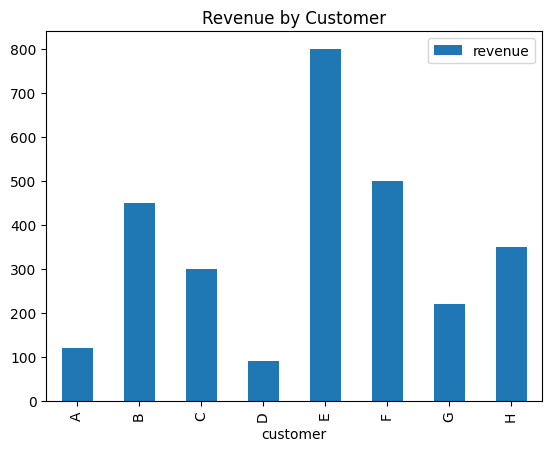

In [94]:
eda.plot(
    x="customer",
    y="revenue",
    kind="bar",
    title="Revenue by Customer"
)
plt.show()

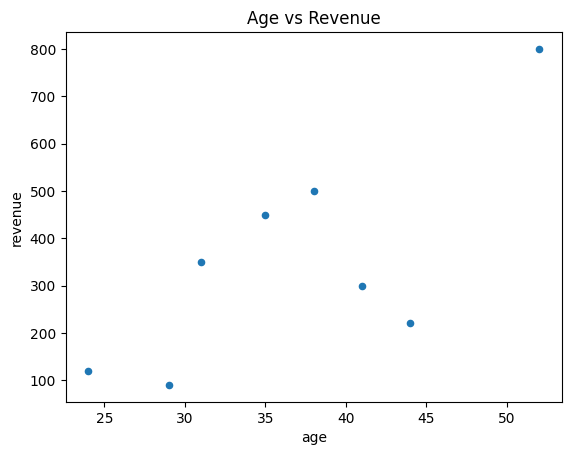

In [95]:
eda.plot(
    x="age",
    y="revenue",
    kind="scatter",
    title="Age vs Revenue"
)
plt.show()

Pandas plotting is convenient for quick analysis. For advanced visualization, use Matplotlib or specialized visualization libraries.

# 30. Practical File I/O

### CSV

```python
df = pd.read_csv("data.csv")
df.to_csv("output.csv", index=False)
```

### Excel

```python
df = pd.read_excel("data.xlsx", sheet_name="Sales")
df.to_excel("output.xlsx", index=False)
```

### JSON

```python
df = pd.read_json("data.json")
df.to_json("output.json", orient="records")
```

### Parquet

Parquet is often a good choice for analytical workflows because it preserves types and is efficient for columnar data.

```python
df = pd.read_parquet("data.parquet")
df.to_parquet("output.parquet")
```

# 31. Performance and Best Practices

## Prefer vectorization

Prefer:

```python
df["total"] = df["price"] * df["quantity"]
```

over manually iterating through rows.

## Select only needed columns

```python
pd.read_csv("large.csv", usecols=["id", "date", "sales"])
```

## Use appropriate dtypes

Categorical columns with a small number of repeated values can use `category`.

## Process large files in chunks

```python
for chunk in pd.read_csv("large.csv", chunksize=100_000):
    process(chunk)
```

## Validate merges

```python
df.merge(other, on="id", validate="many_to_one")
```

## Avoid unnecessary `apply(axis=1)`

It can be much slower than vectorized expressions.

## Be careful with chained assignment

Prefer:

```python
df.loc[df["salary"] > 70000, "label"] = "High"
```

rather than ambiguous chained indexing.

## Keep transformations readable

A short, understandable sequence of operations is usually better than a clever one-liner.

# 32. End-to-End Project — E-Commerce Analytics

We will now combine the major Pandas concepts into one realistic workflow.

## Business questions

1. What is total completed revenue?
2. What is average order value?
3. Which products generate the most revenue?
4. Which categories generate the most revenue?
5. Which cities generate the most revenue?
6. What is monthly revenue?
7. Which customers have the highest lifetime value?
8. What percentage of orders are cancelled?
9. What is the average order value by city?
10. Which product is the best seller by quantity?
11. Which customers placed more than three completed orders?
12. What is the 7-day rolling revenue?
13. Create at least three useful visualizations.

In [96]:
np.random.seed(7)

products = pd.DataFrame({
    "product_id": [101, 102, 103, 104, 105, 106],
    "product": ["Laptop", "Monitor", "Keyboard", "Mouse", "Headphones", "Webcam"],
    "category": ["Computers", "Computers", "Accessories", "Accessories", "Audio", "Accessories"],
    "unit_price": [1200, 450, 100, 50, 180, 90]
})

n = 250

orders = pd.DataFrame({
    "order_id": range(1, n + 1),
    "customer_id": np.random.randint(1000, 1050, n),
    "product_id": np.random.choice(products["product_id"], n),
    "quantity": np.random.randint(1, 5, n),
    "order_date": pd.Timestamp("2026-01-01") + pd.to_timedelta(
        np.random.randint(0, 180, n), unit="D"
    ),
    "city": np.random.choice(
        ["Bogota", "Medellin", "Cali", "Barranquilla"],
        n
    ),
    "status": np.random.choice(
        ["Completed", "Completed", "Completed", "Pending", "Cancelled"],
        n
    )
})

orders = orders.merge(products, on="product_id", how="left")
orders["revenue"] = orders["quantity"] * orders["unit_price"]

orders.head()

,order_id,customer_id,product_id,quantity,order_date,city,status,product,category,unit_price,revenue
0,1,1047,104,1,2026-01-11,Cali,Pending,Mouse,Accessories,50,50
1,2,1004,103,3,2026-05-17,Barranquilla,Completed,Keyboard,Accessories,100,300
2,3,1025,101,3,2026-03-17,Bogota,Completed,Laptop,Computers,1200,3600
3,4,1003,101,2,2026-04-30,Medellin,Completed,Laptop,Computers,1200,2400
4,5,1019,105,1,2026-02-09,Barranquilla,Completed,Headphones,Audio,180,180


## Project Step 1 — Inspect the Dataset

Before doing calculations, inspect the structure, types, missing values, duplicates, and distributions.

In [ ]:
# Your solution here

## Project Step 2 — Clean the Dataset

Check for invalid quantities, invalid prices, missing values, duplicate orders, and unexpected statuses.

In [ ]:
# Your solution here

## Project Step 3 — Completed Revenue

Calculate total completed revenue and average completed order value.

In [ ]:
# Your solution here

## Project Step 4 — Product Analysis

Calculate revenue and quantity by product. Identify the top product by revenue and the top product by quantity.

In [ ]:
# Your solution here

## Project Step 5 — Category Analysis

Calculate total revenue, average order revenue, and number of orders by category.

In [ ]:
# Your solution here

## Project Step 6 — Customer Analysis

Calculate lifetime revenue and completed order count per customer. Find the top 10 customers.

In [ ]:
# Your solution here

## Project Step 7 — City Analysis

Calculate orders, completed revenue, average order value, and cancellation rate by city.

In [ ]:
# Your solution here

## Project Step 8 — Time Analysis

Create a monthly revenue report and identify the best month.

In [ ]:
# Your solution here

## Project Step 9 — Rolling Revenue

Create a daily completed-revenue time series and calculate a 7-day rolling average.

In [ ]:
# Your solution here

## Project Step 10 — Pivot Table

Create a pivot table showing completed revenue by city and category.

In [ ]:
# Your solution here

## Project Step 11 — Visualizations

Create at least three charts:

1. Monthly revenue
2. Revenue by product
3. Revenue by city
4. Orders by status

In [ ]:
# Your solution here

## Project Step 12 — Business Conclusions

Write 5–10 concrete conclusions from the data. Avoid merely describing the code. Explain what the numbers mean.

In [ ]:
# Your conclusions here

# 33. Final Challenge — No Looking Back

Using a new dataset of your choice, perform the complete workflow without copying the
examples above.

Your analysis should contain:

### Data ingestion
- Read CSV, Excel, or another tabular format.

### Data quality
- Inspect types
- Missing values
- Duplicates
- Invalid values

### Transformation
- Create at least three derived columns
- Convert at least one data type
- Use at least one string or datetime operation

### Analysis
- At least two filters
- At least two `groupby` analyses
- At least one `transform`
- At least one merge
- At least one pivot table
- At least one ranking

### Time analysis
- Monthly or weekly aggregation
- At least one rolling calculation

### Visualization
- At least three charts

### Communication
Finish with a short executive summary containing the most important findings.

---

# Pandas Mental Model

A very useful way to think about most Pandas work is:

**LOAD → INSPECT → CLEAN → SELECT → TRANSFORM → COMBINE → GROUP → RESHAPE → ANALYZE → VISUALIZE → EXPORT**

The most important concepts to master are:

```python
df["column"]
df[["a", "b"]]
df.loc[...]
df.iloc[...]
df[condition]
df.assign(...)
df.sort_values(...)
df.groupby(...)
df.agg(...)
df.transform(...)
df.merge(...)
pd.concat(...)
df.pivot_table(...)
df.melt(...)
df.rolling(...)
```

Once these become familiar, you can solve a surprisingly large percentage of real-world
tabular data-analysis problems with Pandas.